In [1]:
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
import numpy as np
import os
import shutil
import zipfile

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path = '/content/drive/MyDrive/RiceLeafsDisease.zip'

In [4]:

from sklearn.model_selection import train_test_split


zip_file_path = '/content/drive/MyDrive/RiceLeafsDisease.zip'
extracted_dir = '/content/RiceLeafsDisease'
output_dir = '/content/organized_dataset'


with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_dir)


print("Extracted directory structure:")
for root, dirs, files in os.walk(extracted_dir):
    print("Root:", root)
    print("Directories:", dirs)
    print("Files:", files)
    print("-" * 40)

for split in ['train', 'validation', 'test']:
    for class_name in ['bacterial_leaf_blight', 'healthy', 'leaf_blast', 'leaf_scald']:
        os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

images = []
labels = []

for class_name in ['bacterial_leaf_blight', 'healthy', 'leaf_blast', 'leaf_scald']:
    class_dir = None
    for root, dirs, files in os.walk(extracted_dir):
        if class_name in dirs:
            class_dir = os.path.join(root, class_name)
            break

    if class_dir is None:
        print(f"Warning: Directory for class '{class_name}' not found. Skipping...")
        continue

    for img in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img)
        if os.path.isfile(img_path):
            images.append(img_path)
            labels.append(class_name)

print(f"Total images found: {len(images)}")

if len(images) == 0:
    raise ValueError("No images found in the dataset. Please check the dataset structure.")

train_images, temp_images, train_labels, temp_labels = train_test_split(
    images, labels, test_size=0.3, stratify=labels, random_state=42
)
val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

def move_images(image_list, labels_list, split):
    for img, label in zip(image_list, labels_list):
        dest_dir = os.path.join(output_dir, split, label)
        shutil.copy(img, dest_dir)

move_images(train_images, train_labels, 'train')
move_images(val_images, val_labels, 'validation')
move_images(test_images, test_labels, 'test')

print("Data has been organized successfully.")
print(f"Train set: {len(train_images)} images")
print(f"Validation set: {len(val_images)} images")
print(f"Test set: {len(test_images)} images")


Extracted directory structure:
Root: /content/RiceLeafsDisease
Directories: ['RiceLeafsDisease']
Files: []
----------------------------------------
Root: /content/RiceLeafsDisease/RiceLeafsDisease
Directories: ['leaf_scald', 'healthy', 'leaf_blast', 'bacterial_leaf_blight']
Files: ['desktop.ini']
----------------------------------------
Root: /content/RiceLeafsDisease/RiceLeafsDisease/leaf_scald
Directories: []
Files: ['leaf_scald (90).jpg', 'Leaf_scald  (933).jpg', 'leaf_scald (57).jpg', 'leaf_scald (168).jpg', 'leaf_scald (245).jpg', 'leaf_scald (223).jpg', 'Leaf_scald  (421).jpg', 'Leaf_scald  (877).jpg', 'leaf_scald (308).jpg', 'Leaf_scald  (352).jpg', 'Leaf_scald  (898).jpg', 'leaf_scald (68).jpg', 'leaf_scald (80).jpg', 'Leaf_scald  (785).jpg', 'Leaf_scald  (36).jpg', 'leaf_scald (89).jpg', 'Leaf_scald  (491).jpg', 'Leaf_scald  (58).jpg', 'leaf_scald (82).jpg', 'leaf_scald (329).jpg', 'leaf_scald (101).jpg', 'leaf_scald (200).jpg', 'leaf_scald (144).jpg', 'leaf_scald (264).jpg', 

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_dir = os.path.join(output_dir, 'train')
validation_dir = os.path.join(output_dir, 'validation')

datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)


test_dir = os.path.join(output_dir, 'test')
test_datagen = ImageDataGenerator(rescale=1.0/255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 1376 images belonging to 4 classes.
Found 295 images belonging to 4 classes.
Found 296 images belonging to 4 classes.


In [36]:


def show_random_images_from_classes(directory, class_names, num_images=5):
    """
    Displays random images from specified classes within a directory.

    Args:
        directory (str): Path to the directory containing the images.
        class_names (list): List of class names (subdirectories).
        num_images (int, optional): Number of images to display per class. Defaults to 5.
    """

    for class_name in class_names:
        class_dir = os.path.join(directory, class_name)
        image_files = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]
        random_images = random.sample(image_files, min(num_images, len(image_files)))

        plt.figure(figsize=(12, 4))
        plt.suptitle(f"Class: {class_name}", fontsize=14)

        for i, image_file in enumerate(random_images):
            image_path = os.path.join(class_dir, image_file)
            img = plt.imread(image_path)

            plt.subplot(1, num_images, i + 1)
            plt.imshow(img)
            plt.axis('off')  # Turn off axis ticks and labels

        plt.show()

In [6]:


base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


<ipython-input-6-a921678decfd>:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator
)


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


43/43 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.5475 - loss: 3.9232 - val_accuracy: 0.7424 - val_loss: 0.5287
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.7552 - loss: 0.6070 - val_accuracy: 0.8000 - val_loss: 0.4623
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.8157 - loss: 0.4625 - val_accuracy: 0.8000 - val_loss: 0.4598
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.8290 - loss: 0.4319 - val_accuracy: 0.8373 - val_loss: 0.3894
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8537 - loss: 0.3347 - val_accuracy: 0.8373 - val_loss: 0.4351
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8628 - loss: 0.3129 - val_accuracy: 0.8102 - val_loss: 0.4194
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8867 - loss: 0.2807 - val_accuracy: 0.8814 - val_loss: 0.3462
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.8919 - loss: 0.2604 - val_accuracy: 0.8678 - val_loss: 0.3171
Epo

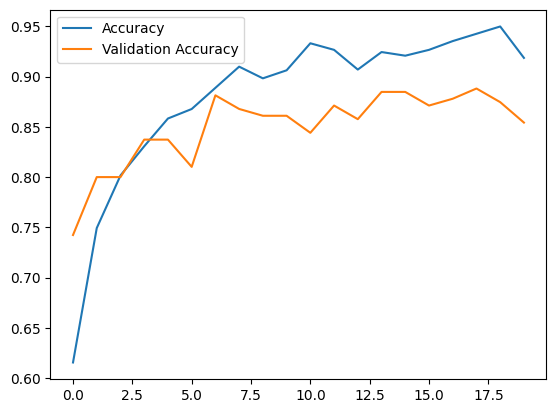

In [8]:


plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()


In [9]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 924ms/step - accuracy: 0.8436 - loss: 0.4949
Test Accuracy: 87.50%


10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 723ms/step


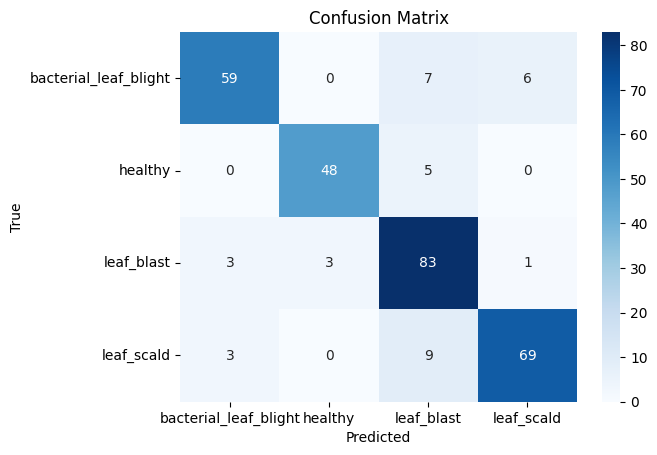

                       precision    recall  f1-score   support

bacterial_leaf_blight       0.91      0.82      0.86        72
              healthy       0.94      0.91      0.92        53
           leaf_blast       0.80      0.92      0.86        90
           leaf_scald       0.91      0.85      0.88        81

             accuracy                           0.88       296
            macro avg       0.89      0.87      0.88       296
         weighted avg       0.88      0.88      0.88       296



In [11]:
!pip install seaborn
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report # Import confusion_matrix and classification_report

y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=1)

conf_matrix = confusion_matrix(y_true, y_pred)  # Now confusion_matrix is defined
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_generator.class_indices.keys()),
            yticklabels=list(test_generator.class_indices.keys()))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))

In [31]:
# from tensorflow.keras.preprocessing import image
# import tensorflow as tf
# import numpy as np
# import matplotlib.pyplot as plt

# def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
#     grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
#     with tf.GradientTape() as tape:
#         conv_outputs, predictions = grad_model(img_array)
#         loss = predictions[:, tf.argmax(predictions[0])]
#     grads = tape.gradient(loss, conv_outputs)
#     pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
#     heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)[0]
#     heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
#     return heatmap

# # Load the image
# img_path = '/content/organized_dataset/train/bacterial_leaf_blight/Bacterial_leaf_Blight (361).jpg'
# img = image.load_img(img_path, target_size=(150, 150))
# img_array = image.img_to_array(img) / 255.0
# img_array = np.expand_dims(img_array, axis=0)

# # Identify the last convolutional layer in MobileNetV2
# for layer in model.layers[0].layers:
#     print(layer.name)  # Print layer names to identify the correct one

# # Update with the correct layer name
# last_conv_layer_name = "block_16_project"  # Replace with the identified layer name

# heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name=last_conv_layer_name)

# # Display the heatmap
# plt.imshow(heatmap)
# plt.colorbar()
# plt.show()

In [17]:
# Save the trained model
model.save('/content/rice_disease_model.h5')
print("Model saved as rice_disease_model.h5")


Model saved as rice_disease_model.h5


In [20]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = '/content/organized_dataset/test/bacterial_leaf_blight/Bacterial_leaf_Blight (613).jpg'  # Replace with the path to your image
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)


predictions = model.predict(img_array)
class_index = np.argmax(predictions)
class_labels = list(train_generator.class_indices.keys())
predicted_class = class_labels[class_index]

print(f"Predicted class: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
Predicted class: bacterial_leaf_blight


In [25]:
from tensorflow.keras.preprocessing import image

def visualize_prediction(img_path, model, class_labels, true_label=None):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(150, 150))  # Match your model's input size
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)


    # Make prediction
    prediction = model.predict(img_array)
    predicted_class = class_labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100


    plt.imshow(image.load_img(img_path))
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)\n"
              f"True: {true_label if true_label else 'Unknown'}", fontsize=12)
    plt.show()




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


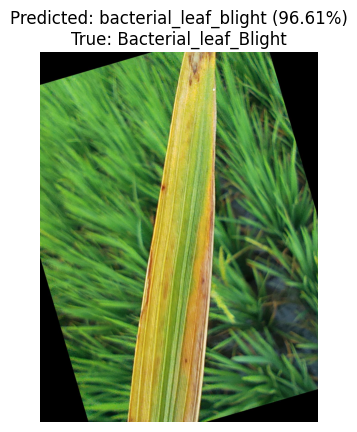

In [27]:
# Example usage
# Example usage
img_path = '/content/organized_dataset/test/bacterial_leaf_blight/Bacterial_leaf_Blight (645).jpg'
true_label = 'Bacterial_leaf_Blight'  # Set the true label of the image
visualize_prediction(img_path, model, list(train_generator.class_indices.keys()), true_label)